# ANÁLISIS ESTADÍSTICO DE LA CLASIFICACIÓN

Este notebook analiza los resultados de la clasificación generada en el notebook 5.
- Correlaciones de Spearman (flux vs variables hidrodinámicas)
- Contraste de hipótesis entre grupos (Mann-Whitney U)
- Asociación spikes–oleaje (Chi-cuadrado)

In [ ]:
import os

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_PATH = '/content/drive/MyDrive/TFM_NoeliaGarciaGarcia/Pipeline'
else:
    BASE_PATH = os.path.abspath(os.path.join(os.path.dirname('__file__'), '..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations
from scipy.stats import (spearmanr, mannwhitneyu, kruskal,
                          chi2_contingency, norm, skew, kurtosis)

pd.set_option("display.max_columns", None)

print(f"Entorno: {'Colab' if IN_COLAB else 'Local'}")
print(f"BASE_PATH: {BASE_PATH}")

Entorno: Local
BASE_PATH: g:\Mi unidad\TFM_NoeliaGarciaGarcia\TFM_OxygenFlux\Pipeline


## Interpretación del p-value



El **p-value** (valor p) es la probabilidad de observar un resultado igual o más extremo que el obtenido, asumiendo que la hipótesis nula es cierta (es decir, que no hay diferencia real entre los grupos).

**Cómo se lee:**
- Si $p < 0{,}05$ → se rechaza la hipótesis nula: existe una diferencia **estadísticamente significativa** entre los grupos de oleaje en cuanto al flujo de oxígeno.
- Si $p \geq 0{,}05$ → no se puede rechazar la hipótesis nula: no hay evidencia suficiente de que los grupos difieran.

**Lectura de la tabla de resultados:**

| Columna | Significado |
|---------|-------------|
| Silhouette | Calidad interna del clustering (0 a 1, cuanto mayor mejor) |
| p-value | Probabilidad bajo $H_0$ de que no haya efecto del oleaje sobre el flujo |
| Significativo | `True` si $p < 0{,}05$ |


# CARGA DATOS

In [ ]:
base_path = os.path.join(BASE_PATH, "DATA", "PROCESSED")

df = pd.read_csv(os.path.join(base_path, "df_classified.csv"))

# Filtrar ventanas con flujo acumulado positivo (coherente con NB3 y NB7)
n_antes = len(df)
if "flag_flux_positivo" in df.columns:
    df = df[~df["flag_flux_positivo"]].copy()
n_despues = len(df)
print(f"Ventanas totales: {n_antes}")
print(f"Eliminadas (flux positivo): {n_antes - n_despues}")
print(f"Ventanas restantes: {n_despues}")

Ventanas totales: 568
Eliminadas (flux positivo): 0
Ventanas restantes: 568


In [ ]:
# ============================================================
# PREPARACION DE DATOS
# ============================================================

# Columnas de clasificación disponibles
clase_cols = {
    "Wiberg": "oleaje_clase_Wiberg",
    "SIMAR": "oleaje_clase_SIMAR",
}

# Verificar cuáles existen
for nombre, col in list(clase_cols.items()):
    if col not in df.columns:
        print(f"⚠️  No se encontró columna '{col}' — se omite escenario {nombre}")
        del clase_cols[nombre]

print("Escenarios disponibles:", list(clase_cols.keys()))
print(f"Total ventanas: {len(df)}")

# Variables de oleaje
vars_oleaje = {
    "Oleaje": "Oleaje",
    "Mod_orbital": "Mod_orbital",
    "STD_orbital": "STD_orbital",
    "Oleaje_SIMAR": "Oleaje_SIMAR",
    "mean_pres": "pres__mean",
    "std_pres": "pres__standard_deviation",
}
# Solo las que existan
vars_oleaje = {k: v for k, v in vars_oleaje.items() if v in df.columns}

ALPHA = 0.05
print(f"Variables de oleaje: {list(vars_oleaje.keys())}")

Escenarios disponibles: ['Wiberg', 'SIMAR']
Total ventanas: 568
Variables de oleaje: ['Oleaje', 'Mod_orbital', 'STD_orbital', 'Oleaje_SIMAR', 'mean_pres', 'std_pres']


# Caracterización de los clusters
Tabla con número de ventanas, oleaje medio, flujo medio y desviación típica del flujo por estado, para ambas configuraciones.

In [ ]:
# ============================================================
# CARACTERIZACIÓN DE CLUSTERS (ambas configuraciones)
# ============================================================

# Configuraciones a comparar
configs = {
    "Wiberg (k=4)": {"col_clase": "oleaje_clase_Wiberg", "col_oleaje": "Oleaje"},
    "SIMAR (k=4)":  {"col_clase": "oleaje_clase_SIMAR",  "col_oleaje": "Oleaje_SIMAR"},
}

for config_name, cfg in configs.items():
    col_clase = cfg["col_clase"]
    col_oleaje = cfg["col_oleaje"]

    if col_clase not in df.columns:
        print(f"⚠️  {col_clase} no encontrada, se omite {config_name}")
        continue

    tabla = df.groupby(col_clase).agg(
        n=("flux_O2", "count"),
        oleaje_media=(col_oleaje, "mean"),
        oleaje_mediana=(col_oleaje, "median"),
        flujo_medio=("flux_O2", "mean"),
        flujo_std=("flux_O2", "std"),
        flujo_mediana=("flux_O2", "median"),
    ).round(4)

    print(f"\n{'='*60}")
    print(f"CARACTERIZACIÓN — {config_name}")
    print(f"{'='*60}")
    display(tabla)
    print()


CARACTERIZACIÓN — Wiberg (k=4)


,n,oleaje_media,oleaje_mediana,flujo_medio,flujo_std,flujo_mediana
oleaje_clase_Wiberg,,,,,,
0,118,11.6664,9.910,-7.6215,5.3290,-6.6308
1,157,13.6720,11.716,-9.4447,12.0184,-7.5095
2,139,24.4553,24.412,-15.7581,22.8817,-8.1405
3,154,31.1267,30.830,-18.3345,21.9132,-12.8267




CARACTERIZACIÓN — SIMAR (k=4)


,n,oleaje_media,oleaje_mediana,flujo_medio,flujo_std,flujo_mediana
oleaje_clase_SIMAR,,,,,,
0,108,1.8488,1.86,-7.5829,5.8284,-6.4652
1,137,2.1683,1.85,-9.2153,12.6394,-6.9795
2,157,4.2323,4.24,-17.5300,21.8103,-11.4399
3,166,4.2405,4.22,-15.4362,21.1068,-8.6744


CARACTERIZACIÓN COMPLETA — SIMAR (todas las features de clustering + flujo)


Oleaje_SIMAR                        pres__mean             \
                          count    mean     std median      count       mean   
oleaje_clase_SIMAR                                                             
0                           108  1.8488  0.3810   1.86        108  1612.1057   
1                           137  2.1683  0.7491   1.85        137  1472.6922   
2                           157  4.2323  0.4968   4.24        157  1489.6284   
3                           166  4.2405  0.6373   4.22        166  1594.5492   

                                       pres__standard_deviation          \
                        std     median                    count    mean   
oleaje_clase_SIMAR                                                        
0                   36.1250  1609.9184                      108  4.1107   
1                   40.6240  1479.3028                      137  4.2990   
2                   31.3253  1490.0354                      157  7.6388   
3                   27.2227  1594.2891                      166  7.1052   

                                   pres__median                               \
                       std  median        count       mean      std   median   
oleaje_clase_SIMAR                                                             
0                   0.9428  4.2320          108  1612.1407  36.0693  1610.00   
1                   0.9875  4.3827          137  1472.6593  40.6386  1479.35   
2                   1.3071  7.6539          157  1489.6570  31.3446  1490.15   
3                   1.4311  6.8976          166  1594.5736  27.2204  1594.30   

                   flux_O2                             
                     count     mean      std   median  
oleaje_clase_SIMAR                                     
0                      108  -7.5829   5.8284  -6.4652  
1                      137  -9.2153  12.6394  -6.9795  
2                      157 -17.5300  21.8103 -11.4399  
3                      166 -15.4362  21.1068  -8.6744

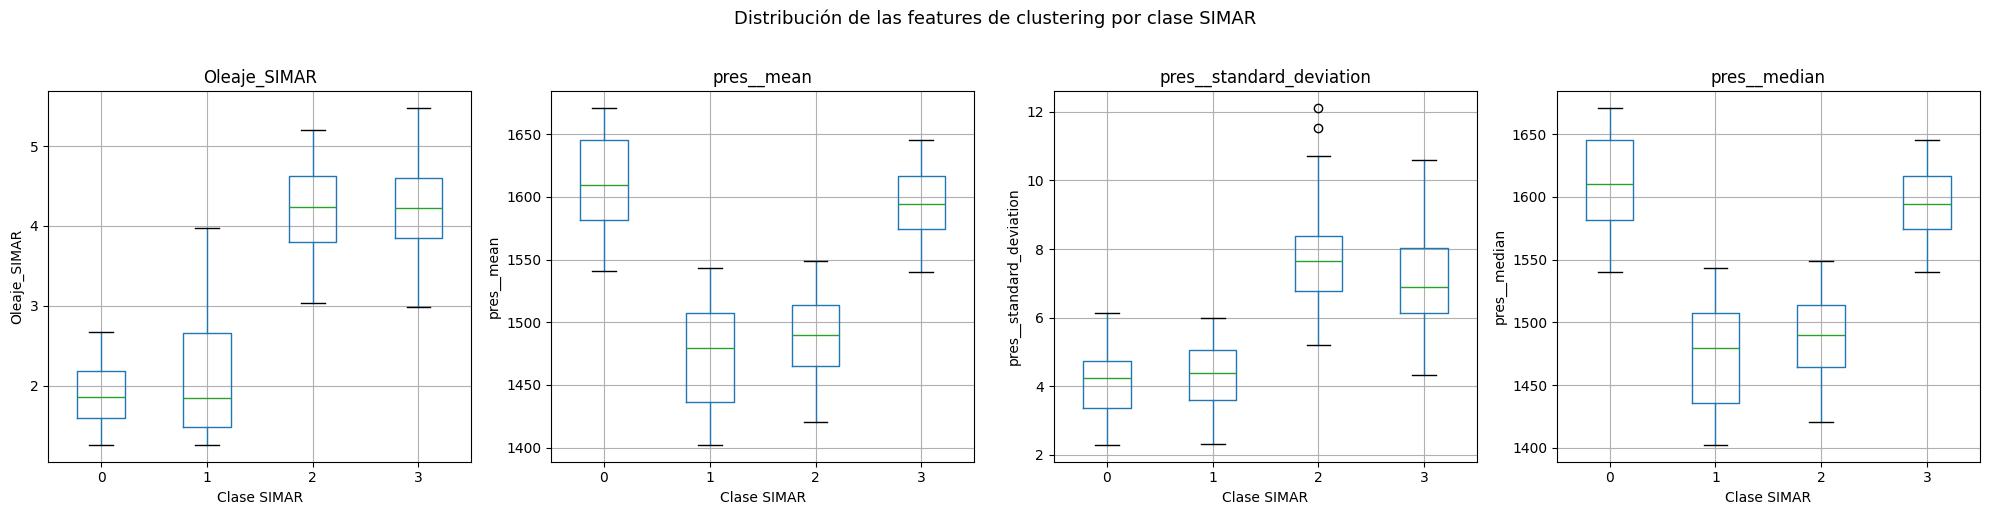

In [5]:
# ============================================================
# ¿Qué diferencia los clusters SIMAR si el oleaje es similar?
# Mostrar TODAS las features usadas en el clustering
# ============================================================

col_clase = "oleaje_clase_SIMAR"
# Features usadas para el clustering SIMAR en NB5
features_simar = ["Oleaje_SIMAR", "pres__mean", "pres__standard_deviation", "pres__median"]
# Añadir flux para contexto
cols_analisis = [c for c in features_simar + ["flux_O2"] if c in df.columns]

tabla_completa = df.groupby(col_clase)[cols_analisis].agg(["count", "mean", "std", "median"]).round(4)
print("CARACTERIZACIÓN COMPLETA — SIMAR (todas las features de clustering + flujo)")
print("="*80)
display(tabla_completa)

# Boxplots de las features de clustering por clase
fig, axes = plt.subplots(1, len(features_simar), figsize=(5*len(features_simar), 5))
if len(features_simar) == 1:
    axes = [axes]

for ax, feat in zip(axes, features_simar):
    if feat in df.columns:
        df.boxplot(column=feat, by=col_clase, ax=ax)
        ax.set_title(feat)
        ax.set_xlabel("Clase SIMAR")
        ax.set_ylabel(feat)

plt.suptitle("Distribución de las features de clustering por clase SIMAR", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Contraste de hipótesis entre grupos
Mann-Whitney U para la clasificación Wiberg. Evalúa si hay diferencia significativa en el flujo entre estados de oleaje.

Asimetría (skewness) = -5.71  (normal = 0)
Curtosis (excess)    = 42.11  (normal = 0)
→ Se descarta normalidad


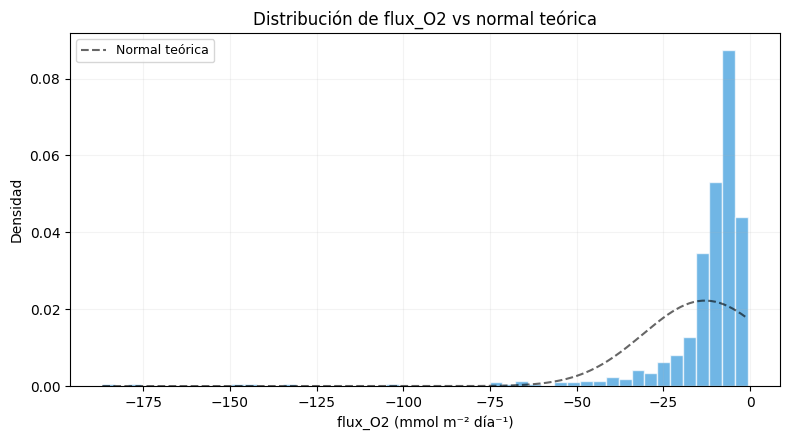

In [6]:
# ============================================================
# JUSTIFICACIÓN DE TESTS NO PARAMÉTRICOS
# Verificación de normalidad de flux_O2
# ============================================================

flux = df["flux_O2"].dropna()

sk = skew(flux)
ku = kurtosis(flux)
print(f"Asimetría (skewness) = {sk:.2f}  (normal = 0)")
print(f"Curtosis (excess)    = {ku:.2f}  (normal = 0)")
print(f"→ Se descarta normalidad")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(flux, bins=50, density=True, color="#3498db", edgecolor="white", alpha=0.7)
x_norm = np.linspace(flux.min(), flux.max(), 300)
ax.plot(x_norm, norm.pdf(x_norm, flux.mean(), flux.std()), "k--", linewidth=1.5, alpha=0.6, label="Normal teórica")
ax.set_xlabel("flux_O2 (mmol m⁻² día⁻¹)")
ax.set_ylabel("Densidad")
ax.set_title("Distribución de flux_O2 vs normal teórica")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.15)
plt.tight_layout()
plt.show()

In [7]:
# ============================================================
# MANN-WHITNEY U / KRUSKAL-WALLIS + BOXPLOTS (ambas configs)
# ============================================================

out_dir = os.path.join(BASE_PATH, "..", "Memoria", "tex", "img")
os.makedirs(out_dir, exist_ok=True)

for nombre, col_clase in clase_cols.items():
    grupos = df[[col_clase, "flux_O2"]].dropna()
    clases = sorted(grupos[col_clase].unique())
    n_clases = len(clases)
    muestras = [grupos.loc[grupos[col_clase] == c, "flux_O2"].values for c in clases]

    print(f"\n{'='*60}")
    print(f"CONTRASTE — {nombre} ({n_clases} clases)")
    print(f"{'='*60}")

    if n_clases == 2:
        stat, p = mannwhitneyu(muestras[0], muestras[1], alternative="two-sided")
        n1, n2 = len(muestras[0]), len(muestras[1])
        r_effect = 1 - (2 * stat) / (n1 * n2)
        print(f"  Test: Mann-Whitney U")
        print(f"  U = {stat:.2f}, p = {p:.6f}")
        print(f"  Tamaño del efecto (rank-biserial r) = {r_effect:.4f}")
        print(f"  Significativo: {p < ALPHA}")
    else:
        stat, p = kruskal(*muestras)
        print(f"  Test: Kruskal-Wallis")
        print(f"  H = {stat:.4f}, p = {p:.6f}")
        print(f"  Significativo: {p < ALPHA}")

        if p < ALPHA:
            pares = list(combinations(clases, 2))
            n_pares = len(pares)
            resultados_posthoc = []
            for c1, c2 in pares:
                m1 = grupos.loc[grupos[col_clase] == c1, "flux_O2"].values
                m2 = grupos.loc[grupos[col_clase] == c2, "flux_O2"].values
                stat_par, p_par = mannwhitneyu(m1, m2, alternative="two-sided")
                resultados_posthoc.append({
                    "grupo_1": c1, "grupo_2": c2,
                    "U": round(stat_par, 2), "p": round(p_par, 6),
                })
            df_ph = pd.DataFrame(resultados_posthoc)
            df_ph["p_bonferroni"] = (df_ph["p"] * n_pares).clip(upper=1.0)
            df_ph["sig"] = df_ph["p_bonferroni"] < ALPHA
            display(df_ph)


CONTRASTE — Wiberg (4 clases)
  Test: Kruskal-Wallis
  H = 70.5112, p = 0.000000
  Significativo: True


,grupo_1,grupo_2,U,p,p_bonferroni,sig
0,0,1,10174.0,0.163063,0.978378,False
1,0,2,10397.0,0.000218,0.001308,True
2,0,3,13994.0,0.000000,0.000000,True
3,1,2,12822.0,0.009352,0.056112,False
4,1,3,17447.0,0.000000,0.000000,True
5,2,3,13344.0,0.000266,0.001596,True



CONTRASTE — SIMAR (4 clases)
  Test: Kruskal-Wallis
  H = 68.8341, p = 0.000000
  Significativo: True


,grupo_1,grupo_2,U,p,p_bonferroni,sig
0,0,1,8018.0,0.260655,1.000000,False
1,0,2,12885.0,0.000000,0.000000,True
2,0,3,11966.0,0.000003,0.000018,True
3,1,2,15453.0,0.000000,0.000000,True
4,1,3,14261.0,0.000141,0.000846,True
5,2,3,10768.0,0.006994,0.041964,True


# Asociación entre spikes y estado de oleaje

In [ ]:
# ============================================================
# CHI-CUADRADO: spikes (flag_outlier_window) vs estado de oleaje
# ============================================================

# Clasificación SIMAR
col_clase = clase_cols.get("SIMAR", list(clase_cols.values())[0])

# Usar solo el flag de spikes (outliers en señal cruda)
flag_col = "flag_outlier_window"
if flag_col not in df.columns:
    print(f"⚠️  Columna '{flag_col}' no encontrada en df")
else:
    df["has_spike"] = df[flag_col].fillna(False).astype(int)

# Correlaciones de Spearman
Correlación no paramétrica entre flux_O2 y todas las variables hidrodinámicas.

In [9]:
# ============================================================
# CORRELACIONES DE SPEARMAN: flux_O2 vs variables hidrodinámicas
# ============================================================

resultados_spear = []

for etiqueta, col_real in vars_oleaje.items():
    aux = df[["flux_O2", col_real]].dropna()
    if len(aux) < 5:
        continue
    rho, p_sp = spearmanr(aux["flux_O2"], aux[col_real])
    resultados_spear.append({
        "Variable": etiqueta,
        "Columna": col_real,
        "Spearman ρ": round(rho, 4),
        "p-value": round(p_sp, 6),
        "Significativo": p_sp < ALPHA,
        "n": len(aux),
    })

df_spearman = pd.DataFrame(resultados_spear)
print("Correlaciones Spearman: flux_O2 vs variables de oleaje")
display(df_spearman)

Correlaciones Spearman: flux_O2 vs variables de oleaje


,Variable,Columna,Spearman ρ,p-value,Significativo,n
0,Oleaje,Oleaje,-0.2681,0.000000,True,511
1,Mod_orbital,Mod_orbital,-0.3770,0.000000,True,568
2,STD_orbital,STD_orbital,-0.3705,0.000000,True,568
3,Oleaje_SIMAR,Oleaje_SIMAR,-0.3672,0.000000,True,568
4,mean_pres,pres__mean,0.0835,0.046749,True,568
5,std_pres,pres__standard_deviation,-0.3547,0.000000,True,568
